# 02 — Distributions: Análisis Univariado
**Entender cada variable por separado antes de relacionarlas.**

## Variables numéricas — qué observar
- **Centro**: media vs. mediana (si difieren mucho → asimetría o outliers)
- **Dispersión**: std, IQR, rango
- **Forma**: skewness (asimetría), kurtosis (colas pesadas)
- **Modalidad**: unimodal, bimodal, multimodal
- **Outliers**: puntos alejados del cuerpo principal de la distribución

## Skewness y Kurtosis
$$\text{Skewness} = \frac{1}{n}\sum\left(\frac{x_i - \bar{x}}{\sigma}\right)^3 \quad \text{Kurtosis} = \frac{1}{n}\sum\left(\frac{x_i - \bar{x}}{\sigma}\right)^4 - 3$$

- Skewness > 0 → cola derecha (positiva) | < 0 → cola izquierda
- Kurtosis > 0 → colas más pesadas que normal (leptocúrtica) | < 0 → colas livianas

## Variables categóricas — qué observar
- Frecuencias relativas (no absolutas → comparables entre datasets)
- Clases raras (< 1%) — pueden ser ruido o casos especiales
- Dominancia de una categoría → desbalance potencial

In [4]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False,
})

# Mismo dataset que 01_data_profiling (re-generar para independencia de notebooks)
rng = np.random.default_rng(42)
n = 5000
categories = rng.choice(['Electronics', 'Clothing', 'Home', 'Sports', 'Books', 'Beauty'], n,
                         p=[0.25, 0.22, 0.18, 0.15, 0.12, 0.08])
countries  = rng.choice(['US', 'UK', 'DE', 'MX', 'BR', 'FR', 'CA'], n, p=[0.35,0.15,0.12,0.10,0.10,0.10,0.08])
channels   = rng.choice(['organic', 'paid', 'email', 'direct', 'affiliate'], n, p=[0.30,0.25,0.20,0.15,0.10])
devices    = rng.choice(['mobile', 'desktop', 'tablet'], n, p=[0.55, 0.35, 0.10])
price      = np.where(categories == 'Electronics', rng.lognormal(4.5, 0.8, n),
             np.where(categories == 'Clothing',    rng.lognormal(3.5, 0.6, n),
                                                   rng.lognormal(3.2, 0.7, n))).round(2)
qty        = rng.integers(1, 8, n)
discount   = np.where(rng.uniform(0,1,n) < 0.3, rng.uniform(0.05, 0.40, n), 0.0).round(2)
revenue    = (price * qty * (1 - discount)).round(2)
rating     = rng.choice([1,2,3,4,5], n, p=[0.05,0.10,0.20,0.40,0.25]).astype(float)

# Outliers
revenue[rng.choice(n, 15, replace=False)] = rng.uniform(5000, 15000, 15)

df = pd.DataFrame({
    'category': categories, 'country': countries, 'channel': channels, 'device': devices,
    'price': price, 'quantity': qty, 'discount': discount, 'revenue': revenue, 'rating': rating,
})
print(f'Dataset: {df.shape}')

Dataset: (5000, 9)


## 1 — Histograma + KDE + estadísticas

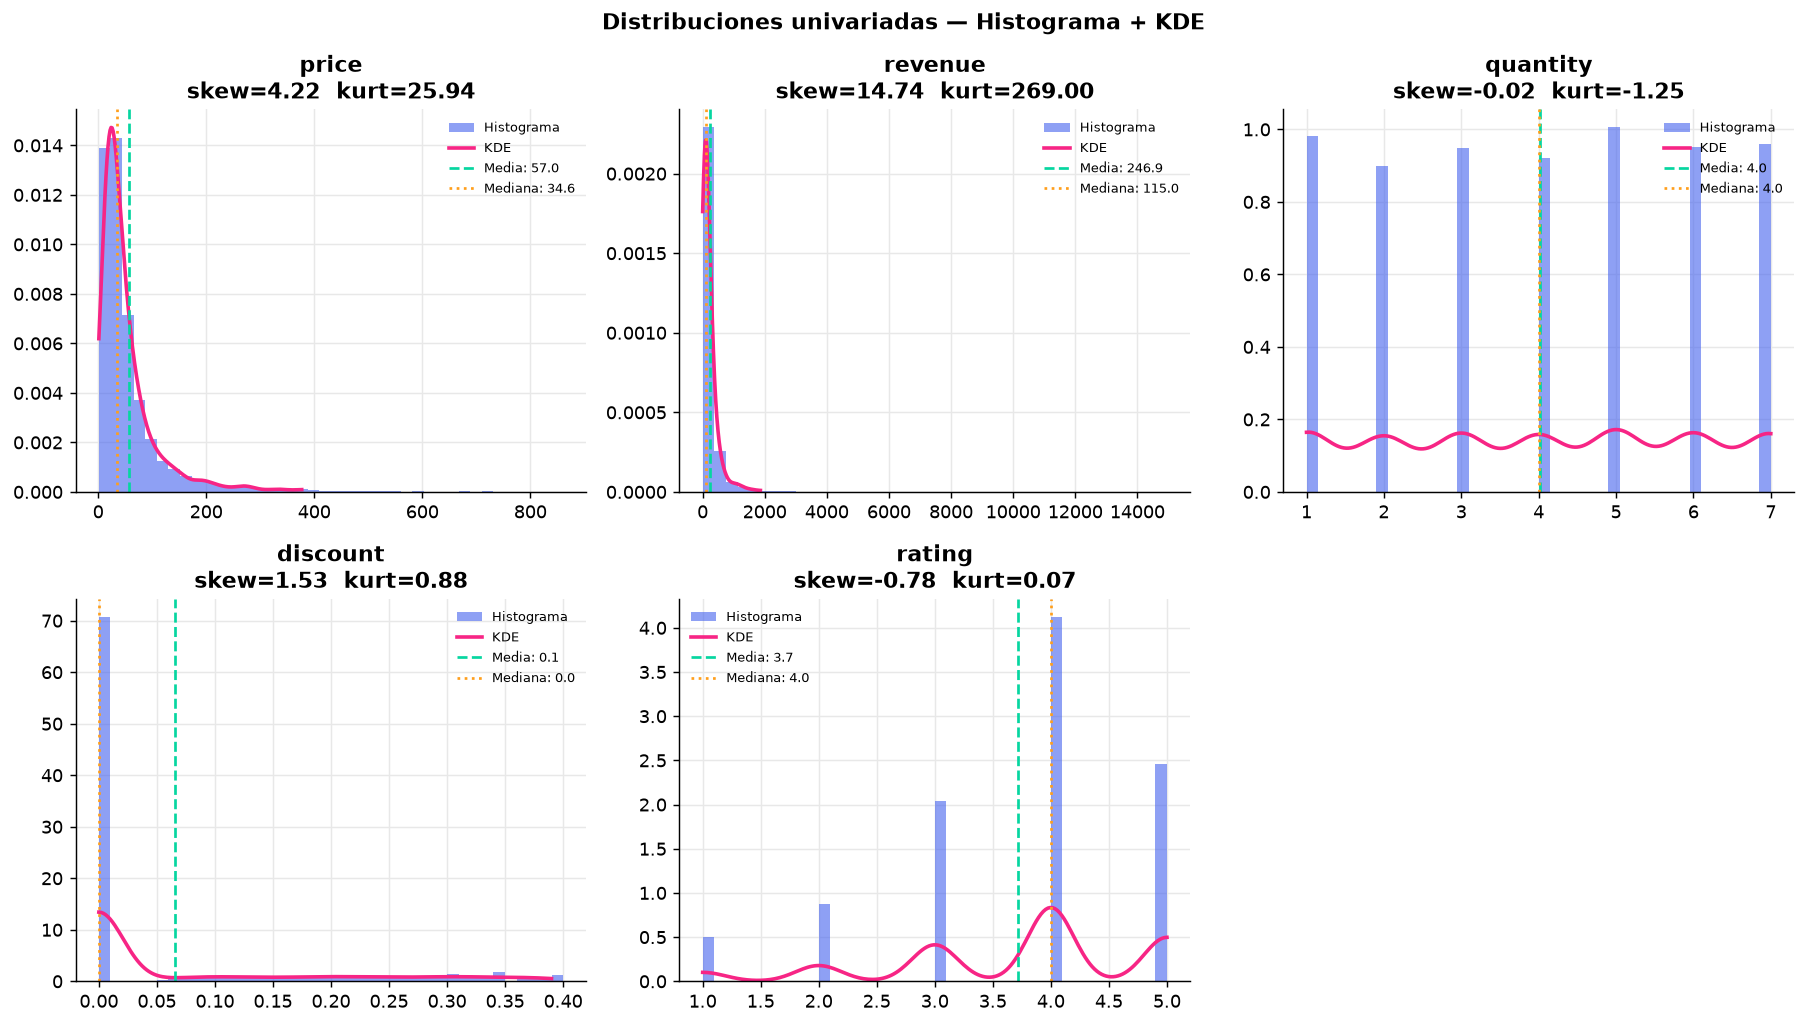

In [5]:
num_cols = ['price', 'revenue', 'quantity', 'discount', 'rating']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    skew = data.skew()
    kurt = data.kurt()

    ax.hist(data, bins=40, color='#4361ee', alpha=0.6, density=True, label='Histograma')

    # KDE
    kde = stats.gaussian_kde(data)
    x   = np.linspace(data.min(), data.quantile(0.99), 200)
    ax.plot(x, kde(x), color='#f72585', linewidth=2, label='KDE')

    # Líneas de media y mediana
    ax.axvline(data.mean(),   color='#06d6a0', linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='#ff9f1c', linestyle=':',  linewidth=1.5, label=f'Mediana: {data.median():.1f}')

    ax.set_title(f'{col}\nskew={skew:.2f}  kurt={kurt:.2f}')
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Distribuciones univariadas — Histograma + KDE', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2 — Box plots: comparar distribuciones y ver outliers

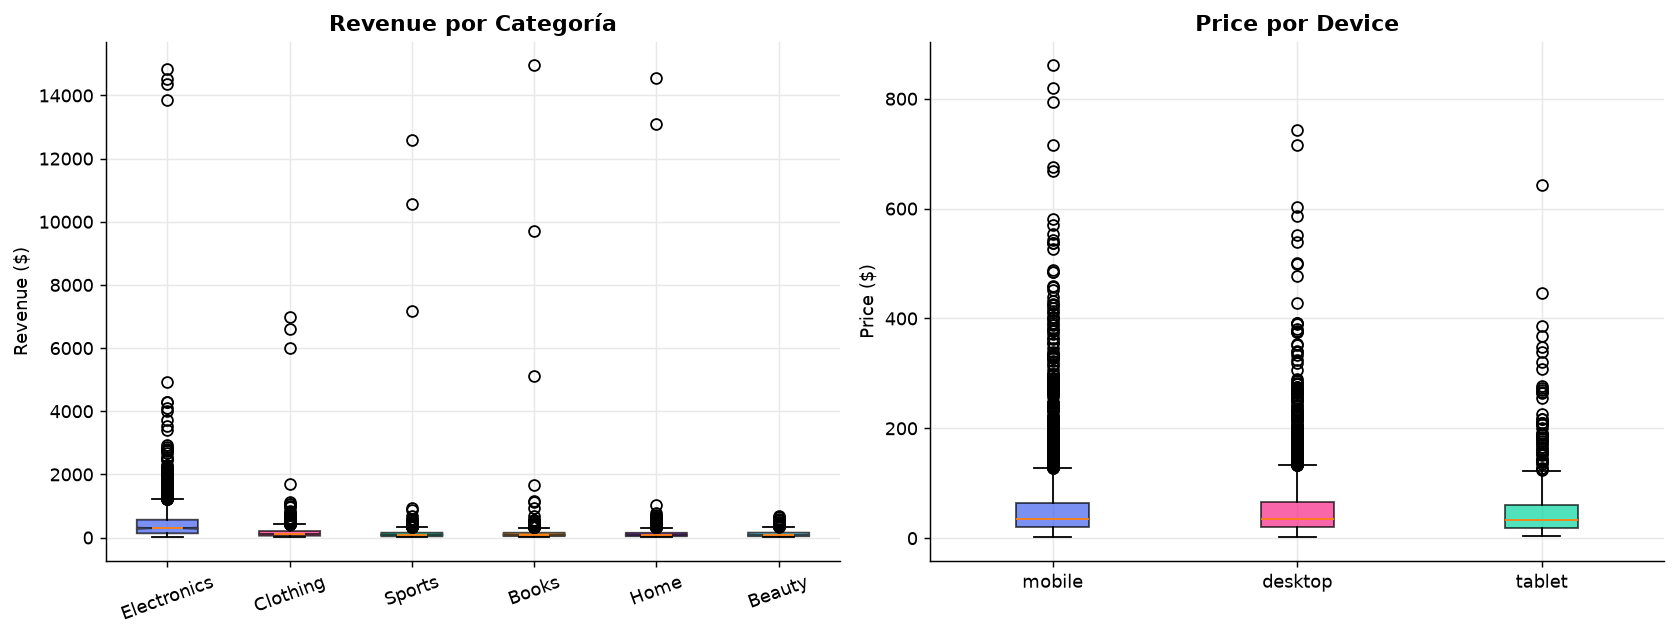

Notch en boxplot: si los notches no se solapan entre grupos → medianas significativamente distintas.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue por categoría
cat_order = df.groupby('category')['revenue'].median().sort_values(ascending=False).index
data_by_cat = [df[df['category'] == c]['revenue'].dropna().values for c in cat_order]
bp = axes[0].boxplot(data_by_cat, tick_labels=cat_order, patch_artist=True, notch=True)
colors = ['#4361ee','#f72585','#06d6a0','#ff9f1c','#7209b7','#4cc9f0']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Revenue por Categoría')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=20)

# Price por device
dev_order = df.groupby('device')['price'].median().sort_values(ascending=False).index
data_by_dev = [df[df['device'] == d]['price'].values for d in dev_order]
bp2 = axes[1].boxplot(data_by_dev, tick_labels=dev_order, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Price por Device')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()
print('Notch en boxplot: si los notches no se solapan entre grupos → medianas significativamente distintas.')

## 3 — Variables categóricas: frecuencias

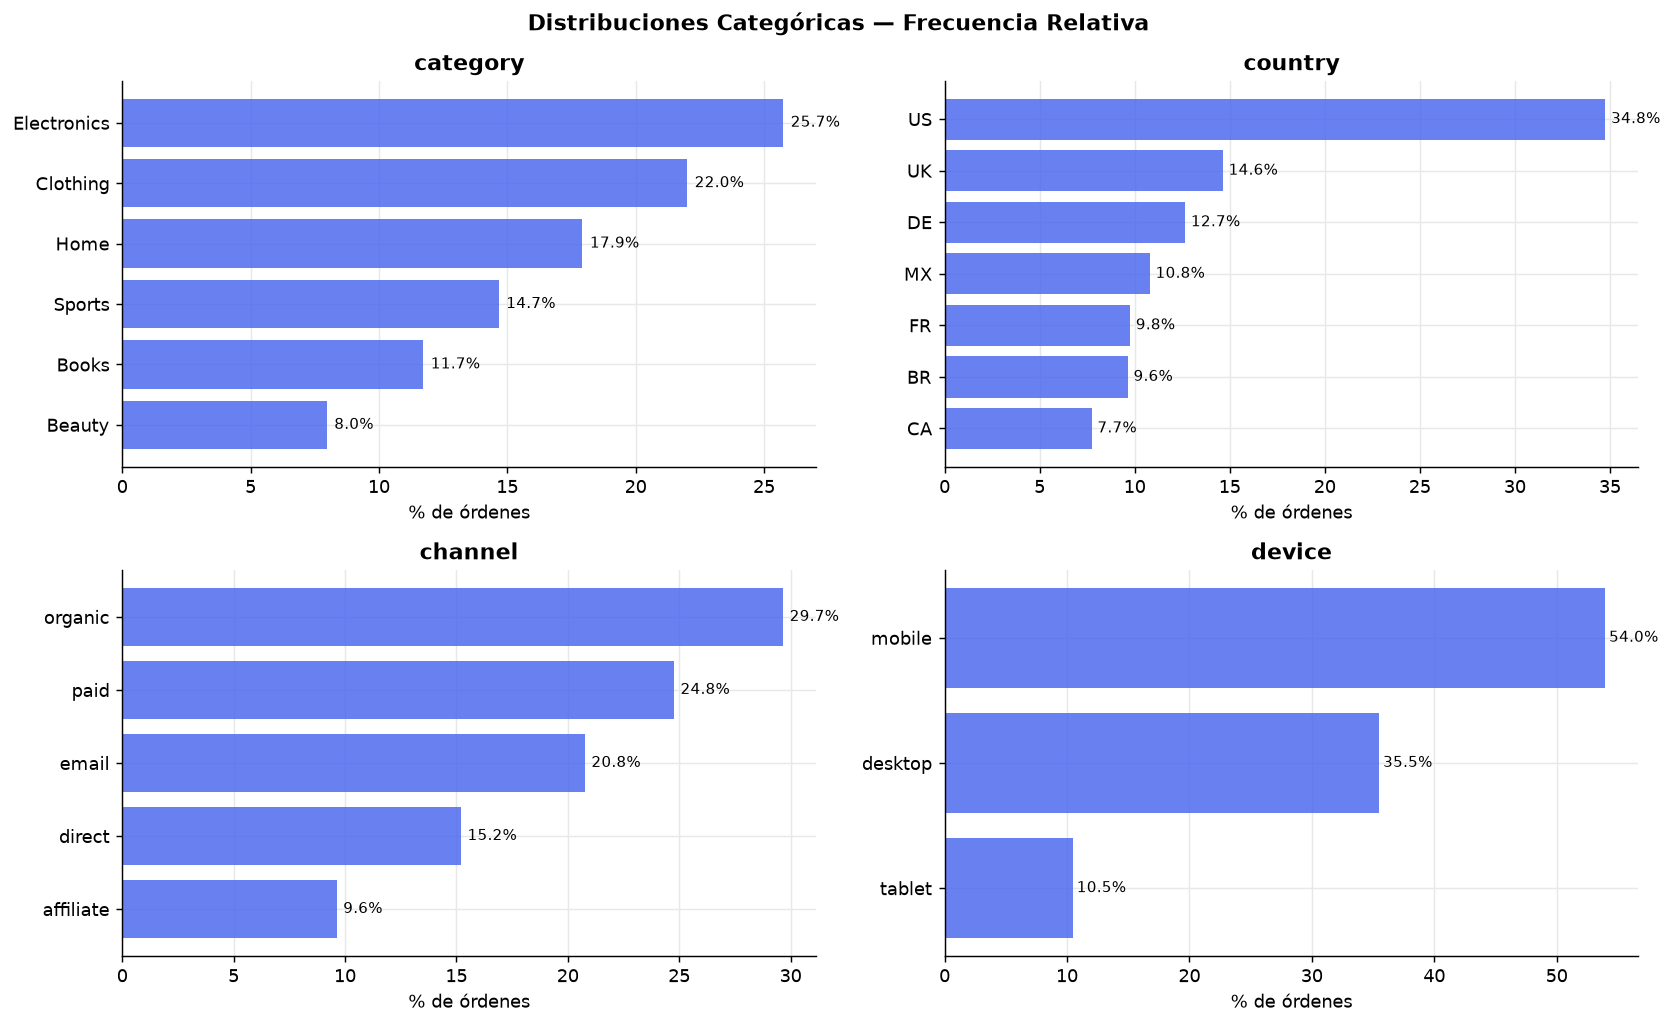

In [7]:
cat_cols = ['category', 'country', 'channel', 'device']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col in zip(axes.flatten(), cat_cols):
    vc = df[col].value_counts(normalize=True).sort_values(ascending=True)
    bars = ax.barh(vc.index, vc.values * 100, color='#4361ee', alpha=0.8)
    ax.set_xlabel('% de órdenes')
    ax.set_title(col)
    for bar, val in zip(bars, vc.values):
        ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=8.5)

plt.suptitle('Distribuciones Categóricas — Frecuencia Relativa', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 — Q-Q Plot: verificar normalidad

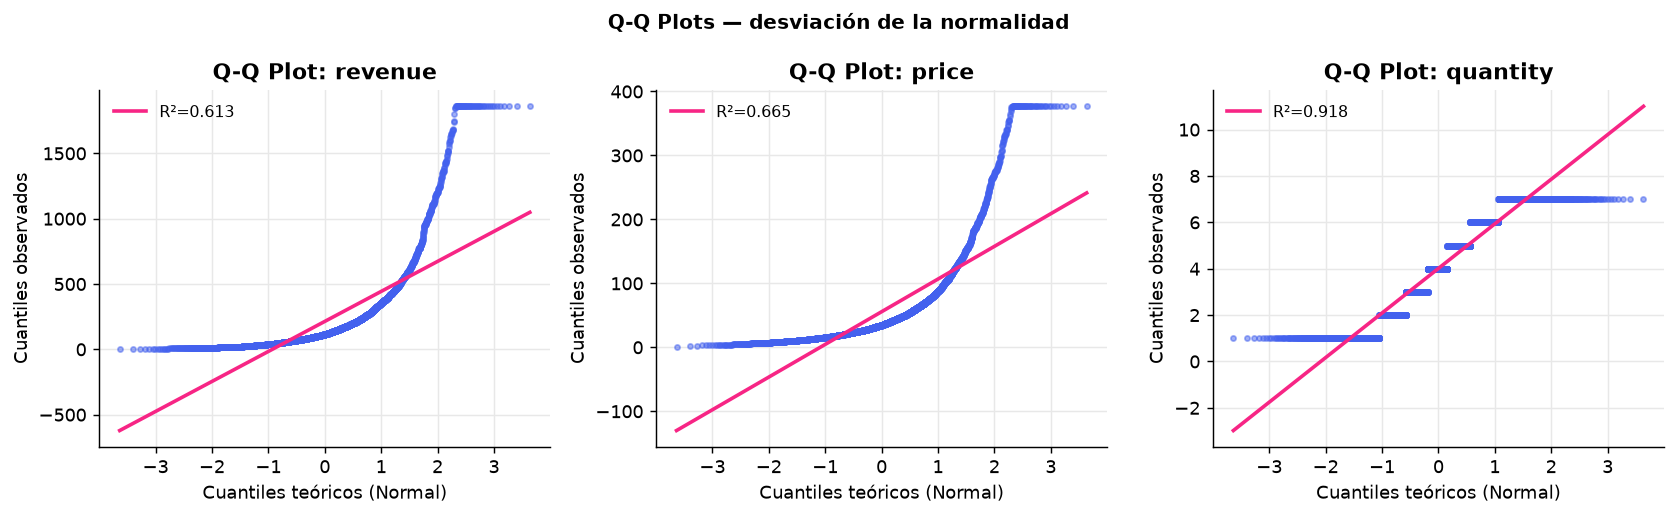

Puntos sobre la línea diagonal → distribución normal.
Cola derecha levantada → skewness positiva (revenue, price).


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (col, clip_q) in zip(axes, [('revenue', 0.99), ('price', 0.99), ('quantity', 1.0)]):
    data = df[col].clip(upper=df[col].quantile(clip_q)).dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, s=8, color='#4361ee', alpha=0.5)
    ax.plot(osm, slope * np.array(osm) + intercept, color='#f72585', linewidth=2, label=f'R²={r**2:.3f}')
    ax.set_xlabel('Cuantiles teóricos (Normal)')
    ax.set_ylabel('Cuantiles observados')
    ax.set_title(f'Q-Q Plot: {col}')
    ax.legend(fontsize=9)

plt.suptitle('Q-Q Plots — desviación de la normalidad', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print('Puntos sobre la línea diagonal → distribución normal.')
print('Cola derecha levantada → skewness positiva (revenue, price).')

## 5 — Transformaciones para normalizar distribuciones sesgadas

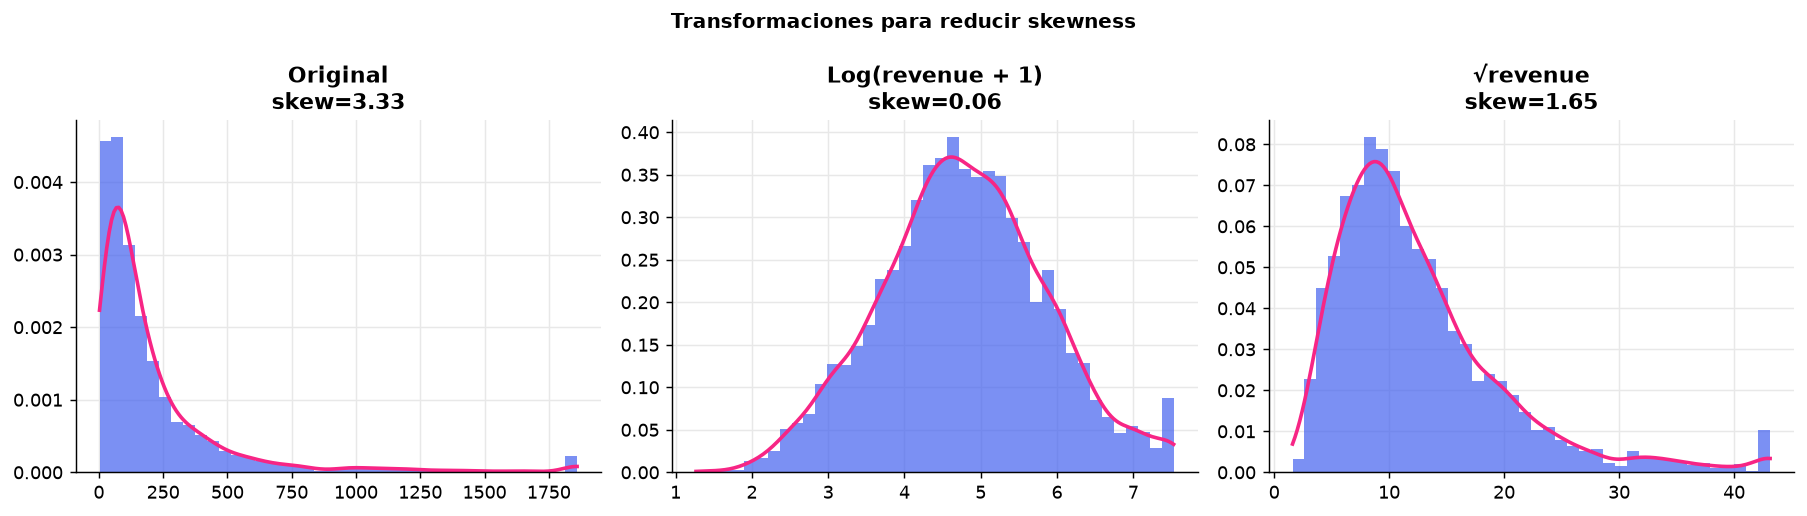

→ Log-transform es la más efectiva para variables con distribución lognormal (precio, revenue).
  Recordar: al predecir, aplicar exp() para volver a la escala original.


In [9]:
# Revenue tiene skewness positiva fuerte → log-transform
rev_clean = df['revenue'].clip(upper=df['revenue'].quantile(0.99))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

transforms = [
    ('Original',         rev_clean),
    ('Log(revenue + 1)', np.log1p(rev_clean)),
    ('√revenue',         np.sqrt(rev_clean)),
]

for ax, (label, data) in zip(axes, transforms):
    ax.hist(data, bins=40, color='#4361ee', alpha=0.7, density=True)
    kde = stats.gaussian_kde(data)
    x   = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, kde(x), color='#f72585', linewidth=2)
    ax.set_title(f'{label}\nskew={data.skew():.2f}')

plt.suptitle('Transformaciones para reducir skewness', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('→ Log-transform es la más efectiva para variables con distribución lognormal (precio, revenue).')
print('  Recordar: al predecir, aplicar exp() para volver a la escala original.')

## Resumen

| Herramienta | Cuándo usarla |
|---|---|
| Histograma | Forma general de la distribución, modalidad |
| KDE | Versión suavizada del histograma, mejor para comparar grupos |
| Box plot | Comparar distribuciones entre grupos, ver outliers |
| Q-Q plot | Verificar normalidad (relevante para tests estadísticos) |
| Frecuencias relativas | Categóricas: proporciones comparables entre datasets |
| Log-transform | Revenue, precio, tiempo — variables con skewness positiva fuerte |

**Siguiente:** `03_relationships.ipynb`